>> K Means Clustring


In [19]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [20]:
x, y_true = make_blobs(n_samples=300,  cluster_std=1, random_state=42)
df = pd.DataFrame(x, columns=['f1', 'f2'])
df.head()


,f1,f2
0,-7.338988,-7.729954
1,-7.740041,-7.264665
2,-1.686653,7.793442
3,4.422198,3.071947
4,-8.917752,-7.888196


In [21]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

In [22]:
inertia = []
krange = range(1, 11)
for k in krange:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)
inertia

c:\Users\Rawknee\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Rawknee\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Rawknee\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Rawknee\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\

[600.0,
 187.7999194617591,
 18.263159330895952,
 15.455336312434504,
 12.715907526929659,
 10.690463801076879,
 9.481197524069948,
 8.372879644023598,
 7.419344942683909,
 6.6800356198615205]

Text(0.5, 0, 'Number of Clusters (k)')

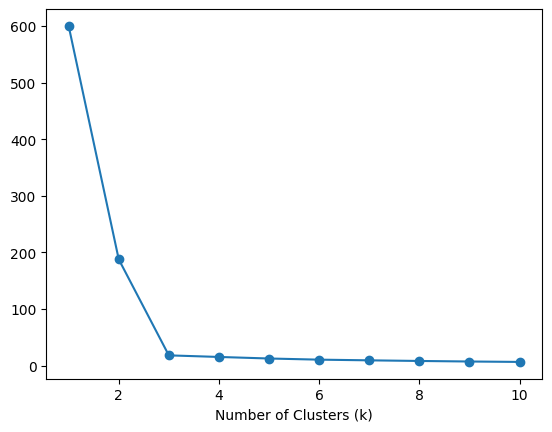

In [23]:
plt.plot(krange, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')

c:\Users\Rawknee\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


<Axes: xlabel='f1', ylabel='f2'>

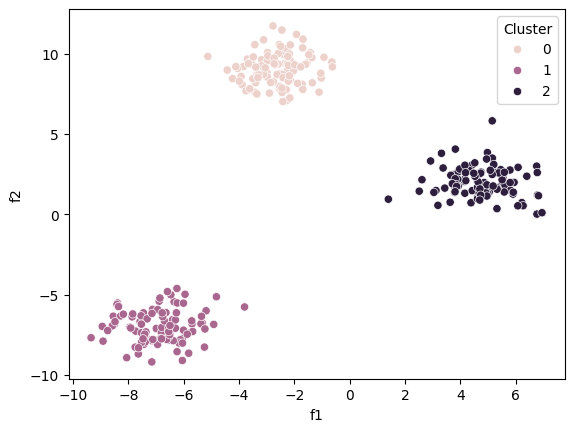

In [24]:
k_means_final = KMeans(n_clusters=3, random_state=42)
k_means_final.fit(x_scaled)
labels = k_means_final.labels_
df['Cluster'] = labels
sns.scatterplot(data=df, x='f1', y='f2', hue='Cluster')

> DB Scan

c:\Users\Rawknee\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


<Axes: xlabel='f1', ylabel='f2'>

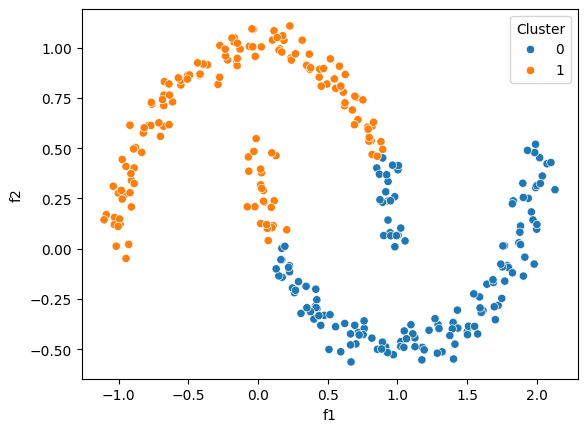

In [35]:
from sklearn.datasets import make_moons
x_db, y_db = make_moons(n_samples=300, noise=0.05, random_state=42)
x_db_scaled = scaler.fit_transform(x_db)
k_means_db = KMeans(n_clusters=2, random_state=42)
k_means_db.fit(x_db_scaled)
labels_db = k_means_db.labels_
df_db = pd.DataFrame(x_db, columns=['f1', 'f2'])   
df_db['Cluster'] = labels_db
sns.scatterplot(data=df_db, x='f1', y='f2', hue='Cluster')

this shows that kmeans clustering only works for circular data

In [36]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=0.3, min_samples=5)

dbscan_labels = dbscan.fit_predict(x_db_scaled)
df_db['DBSCAN_Cluster'] = dbscan_labels

<Axes: xlabel='f1', ylabel='f2'>

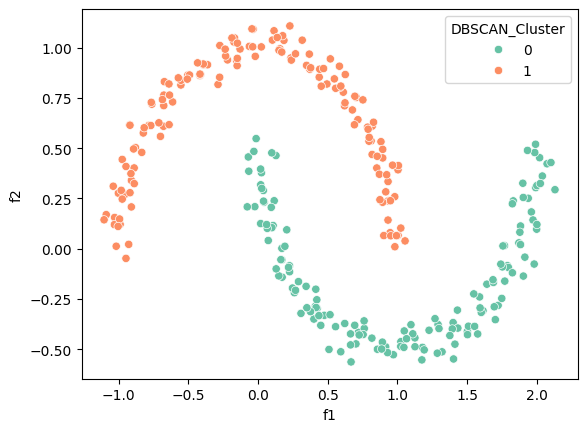

In [37]:
sns.scatterplot(data=df_db, x='f1', y='f2', hue='DBSCAN_Cluster', palette='Set2')